# BERT: tokens, embeddings, attention, and a classifier


## From text to tokens


In [54]:
from transformers import AutoTokenizer, AutoModel
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
text = 'hi there'
print(tokenizer.tokenize(text))
print(tokenizer.encode(text))
print(tokenizer.decode(tokenizer.encode(text)))

['hi', 'there']
[101, 7632, 2045, 102]
[CLS] hi there [SEP]


## Words and WordPieces


In [55]:
words = ['cat', 'cats', 'puppy', 'unhappiness', 'water', 'Water']
for word in words:
    print(f'{word:>12} ? {tokenizer.tokenize(word)} ? {tokenizer.encode(word, add_special_tokens=False)}')

         cat ? ['cat'] ? [4937]
        cats ? ['cats'] ? [8870]
       puppy ? ['puppy'] ? [17022]
 unhappiness ? ['un', '##ha', '##pp', '##iness'] ? [4895, 3270, 9397, 9961]
       water ? ['water'] ? [2300]
       Water ? ['water'] ? [2300]


## Special tokens and sentence pairs


In [56]:
sentence_a = 'We drink water'
sentence_b = 'They water the plants'
inputs = tokenizer(sentence_a, sentence_b, return_tensors='pt')
print(inputs['input_ids'].shape)
print(tokenizer.convert_ids_to_tokens(inputs['input_ids'][0].tolist()))
print('segment IDs:', inputs['token_type_ids'][0].tolist())
print('attention mask:', inputs['attention_mask'][0].tolist())

torch.Size([1, 10])
['[CLS]', 'we', 'drink', 'water', '[SEP]', 'they', 'water', 'the', 'plants', '[SEP]']
segment IDs: [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]
attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


## Pretrained token embeddings


In [57]:
bert = AutoModel.from_pretrained('bert-base-uncased', attn_implementation='eager')
bert.eval()
weight = bert.embeddings.word_embeddings.weight.detach()
normed_weight = weight / weight.norm(p=2, dim=-1, keepdim=True).clamp_min(1e-12)
print(weight.shape)

def token_id(word):
    ids = tokenizer.encode(word, add_special_tokens=False)
    if len(ids) != 1 or ids[0] == tokenizer.unk_token_id:
        raise ValueError(f'{word!r} is not one known WordPiece: {tokenizer.convert_ids_to_tokens(ids)}')
    return ids[0]

word = 'cat'
print(token_id(word), tokenizer.convert_ids_to_tokens(token_id(word)))
print(weight[token_id(word)][:12])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


torch.Size([30522, 768])
4937 cat
tensor([ 0.0091, -0.0665, -0.0069, -0.0331, -0.0371,  0.0081,  0.0005,  0.0135,
        -0.0038,  0.0122, -0.0635, -0.0022])


## Comparing embeddings


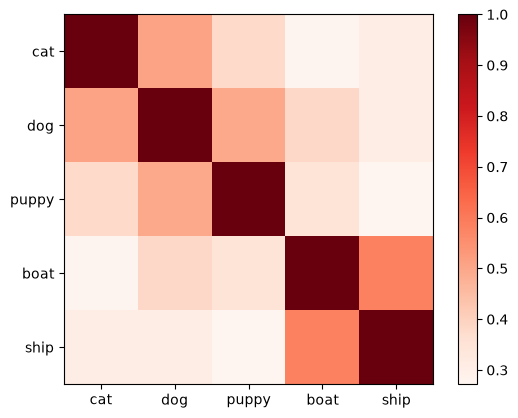

In [58]:
words = ['cat', 'dog', 'puppy', 'boat', 'ship']
ids = [token_id(word) for word in words]
similarity = normed_weight[ids] @ normed_weight[ids].T
fig, ax = plt.subplots()
im = ax.imshow(similarity, cmap='Reds')
ax.set(xticks=range(len(words)), yticks=range(len(words)),
       xticklabels=words, yticklabels=words)
fig.colorbar(im, ax=ax)
plt.show()

## Embedding arithmetic


In [59]:
def get_difference(base, v1, v2):
    base_id, v1_id, v2_id = [token_id(word) for word in (base, v1, v2)]
    target = normed_weight[base_id] + normed_weight[v1_id] - normed_weight[v2_id]
    scores = normed_weight @ target
    scores[list(tokenizer.all_special_ids)] = -float('inf')
    scores[[base_id, v1_id, v2_id]] = -float('inf')
    return tokenizer.convert_ids_to_tokens(scores.argmax().item())

get_difference('king', 'woman', 'man')

'queen'

## Attention in pretrained BERT


In [60]:
with torch.inference_mode():
    outputs = bert(**inputs, output_attentions=True)
print(len(outputs.attentions), outputs.attentions[0].shape)

12 torch.Size([1, 12, 10, 10])


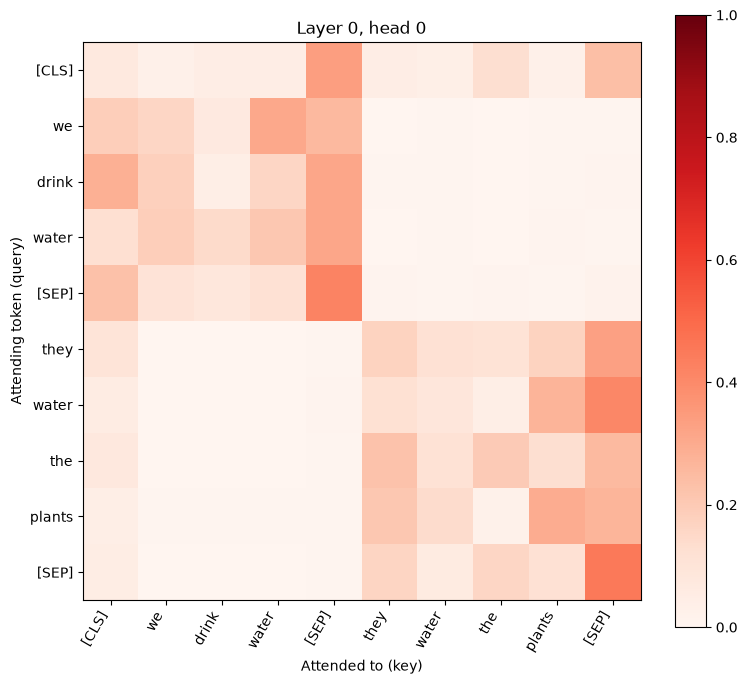

In [61]:
layer = 0
head = 0
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0].tolist())
attention = outputs.attentions[layer][0, head].cpu()
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(attention, vmin=0, vmax=1, cmap='Reds')
ax.set(xticks=range(len(tokens)), yticks=range(len(tokens)),
       xticklabels=tokens, yticklabels=tokens,
       xlabel='Attended to (key)', ylabel='Attending token (query)',
       title=f'Layer {layer}, head {head}')
plt.setp(ax.get_xticklabels(), rotation=60, ha='right')
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Yelp reviews: data for a classifier from scratch

We took the baseline bert tokenizer and removed all the tokens that dont apear in our data.
then we will run the entire thing

In [19]:
from yelp_data import load_yelp_data

device = (torch.accelerator.current_accelerator()
          if torch.accelerator.is_available() else torch.device('cpu'))
MAX_LEN = 512 #(same as bert and we use this constant for choosing the tokenizer. it can be changed but better not)
BATCH_SIZE = 2048
D_MODEL = 32
LAYERS = 2
EPOCHS = 1
MAX_TRAIN_STEPS = None
MAX_TEST_STEPS = None

classifier_tokenizer, train_loader, test_loader = load_yelp_data(
    max_len=MAX_LEN, rare_token_limit=5, batch_size=BATCH_SIZE)
VOCAB_SIZE = len(classifier_tokenizer)
PAD_ID = classifier_tokenizer.pad_token_id
ids, labels = next(iter(train_loader))
print(device, ids.shape, labels.shape, VOCAB_SIZE)
print(classifier_tokenizer.convert_ids_to_tokens(ids[0, :16].tolist()))

xpu torch.Size([2048, 512]) torch.Size([2048]) 23767
['[CLS]', 'not', 'the', 'best', 'in', 'customer', 'service', '.', 'i', 'did', 'purchase', 'the', 'group', '##on', 'for', 'this']


## Bidirectional attention


In [20]:
from torch import nn

def attention_math(q, k, v, scale):
    scores = (q @ k.transpose(-2, -1)) * scale
    return torch.softmax(scores, dim=-1) @ v

class Attention(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.q = nn.Linear(d, d, bias=False)
        self.k = nn.Linear(d, d, bias=False)
        self.v = nn.Linear(d, d, bias=False)
        self.scale = d ** -0.5

    def forward(self, x):
        return attention_math(self.q(x), self.k(x), self.v(x), self.scale)

## Encoder and classification head


In [21]:
class Embed(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.tok = nn.Embedding(VOCAB_SIZE, d, padding_idx=PAD_ID)
        self.pos = nn.Embedding(MAX_LEN, d)
        self.dropout = nn.Dropout(0.1)

    def forward(self, ids):
        positions = torch.arange(ids.shape[1], device=ids.device)
        return self.dropout(self.tok(ids) + self.pos(positions))

class Block(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.norm1 = nn.LayerNorm(d)
        self.attention = Attention(d)
        self.norm2 = nn.LayerNorm(d)
        self.mlp = nn.Sequential(nn.Linear(d, 4 * d), nn.GELU(), nn.Linear(4 * d, d))

    def forward(self, x):
        x = x + self.attention(self.norm1(x))
        return x + self.mlp(self.norm2(x))

class BertStyleClassifier(nn.Module):
    def __init__(self, d, layers):
        super().__init__()
        self.embed = Embed(d)
        self.blocks = nn.ModuleList([Block(d) for _ in range(layers)])
        self.norm = nn.LayerNorm(d)
        self.head = nn.Linear(d, 2)

    def forward(self, ids):
        x = self.embed(ids)
        for block in self.blocks:
            x = block(x)
        return self.head(self.norm(x[:, 0]))

model = BertStyleClassifier(D_MODEL, LAYERS).to(device)
print(f'Randomly initialized parameters: {sum(p.numel() for p in model.parameters()):,}')

Randomly initialized parameters: 800,162


## Training and evaluation


In [22]:
from collections import deque
from itertools import islice
import time
import numpy as np
from tqdm.auto import tqdm

def run_epoch(model, loader, opt=None, max_steps=None, loss_history=None):
    training = opt is not None
    model.train(training)
    total_loss = total_correct = total_examples = 0
    recent = deque(maxlen=20)
    count = min(len(loader), max_steps) if max_steps is not None else len(loader)
    start = time.perf_counter()
    progress = tqdm(islice(loader, max_steps), total=count,
                    desc='Train' if training else 'Test', unit='batch')
    with torch.set_grad_enabled(training):
        for host_ids, host_labels in progress:
            ids = host_ids.to(device, non_blocking=True)
            labels = host_labels.to(device, non_blocking=True)
            if training:
                opt.zero_grad()
            logits = model(ids)
            loss = F.cross_entropy(logits.reshape(-1, 2), labels.reshape(-1))
            if training:
                loss.backward()
                opt.step()
            n = labels.numel()
            batch_loss = loss.item()
            batch_correct = (logits.argmax(dim=-1) == labels).sum().item()
            if training and loss_history is not None:
                loss_history.append(batch_loss)
            total_loss += batch_loss * n
            total_correct += batch_correct
            total_examples += n
            recent.append((batch_loss * n, batch_correct, n))
            recent_examples = sum(item[2] for item in recent)
            progress.set_postfix(loss=f'{total_loss / total_examples:.3f}',
                                 acc=f'{total_correct / total_examples:.1%}',
                                 last20_loss=f'{sum(item[0] for item in recent) / recent_examples:.3f}',
                                 last20_acc=f'{sum(item[1] for item in recent) / recent_examples:.1%}')
    return {'loss': total_loss / total_examples,
            'accuracy': total_correct / total_examples,
            'examples': total_examples, 'seconds': time.perf_counter() - start}

ids, labels = next(iter(train_loader))
logits = model(ids.to(device))
assert logits.shape == (len(labels), 2)
F.cross_entropy(logits, labels.to(device)).backward()
model.zero_grad(set_to_none=True)
print('Forward/backward check passed')

Forward/backward check passed


In [23]:
opt = torch.optim.AdamW(model.parameters(), lr=2e-3)
train_losses = []
test_points = []
for epoch in range(EPOCHS):
    print(f'Epoch {epoch + 1}/{EPOCHS}')
    train_result = run_epoch(model, train_loader, opt, MAX_TRAIN_STEPS, train_losses)
    print('train:', train_result)
    test_result = run_epoch(model, test_loader, max_steps=MAX_TEST_STEPS)
    print('test:', test_result)
    test_points.append((len(train_losses), test_result['loss']))

Epoch 1/1


Train:   0%|          | 0/274 [00:00<?, ?batch/s]

train: {'loss': 0.4643641708578382, 'accuracy': 0.7556053571428571, 'examples': 560000, 'seconds': 339.9872747999616}


Test:   0%|          | 0/19 [00:00<?, ?batch/s]

test: {'loss': 0.24870731891456405, 'accuracy': 0.8982368421052631, 'examples': 38000, 'seconds': 10.474561899900436}


## Loss curves


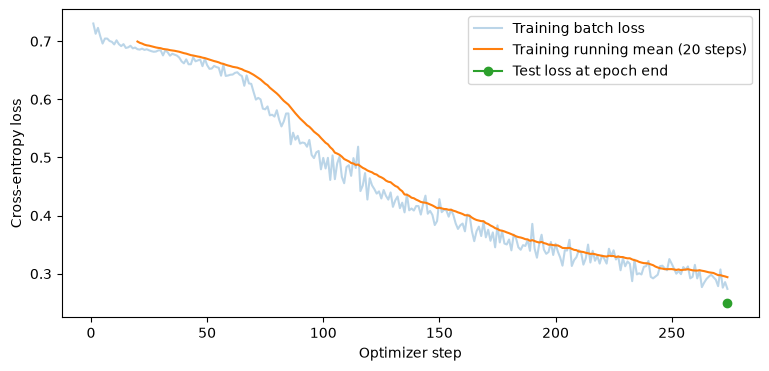

In [24]:
steps = np.arange(1, len(train_losses) + 1)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(steps, train_losses, alpha=0.3, label='Training batch loss')
window = min(20, len(train_losses))
if window:
    smoothed = np.convolve(train_losses, np.ones(window) / window, mode='valid')
    ax.plot(steps[window - 1:], smoothed, label=f'Training running mean ({window} steps)')
if test_points:
    test_steps, test_losses = zip(*test_points)
    ax.plot(test_steps, test_losses, 'o-', label='Test loss at epoch end')
ax.set(xlabel='Optimizer step', ylabel='Cross-entropy loss')
ax.legend()
plt.show()

# Lets look on the model we trained

In [62]:
def token_id(word):
    ids = classifier_tokenizer.encode(word, add_special_tokens=False)
    if len(ids) != 1 or ids[0] == classifier_tokenizer.unk_token_id:
        raise ValueError(f'{word!r} is not one known WordPiece: {classifier_tokenizer.convert_ids_to_tokens(ids)}')
    return ids[0]
    
weight = model.embed.tok.weight.detach().cpu()
normed_weight = weight / weight.norm(p=2, dim=-1, keepdim=True).clamp_min(1e-12)
normed_weight

tensor([[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [-0.1833, -0.0214, -0.0414,  ...,  0.3969,  0.0022, -0.2432],
        [-0.0614, -0.1079, -0.0222,  ...,  0.2277, -0.1821,  0.1934],
        ...,
        [-0.2992,  0.0072, -0.1519,  ..., -0.0426,  0.0118,  0.0564],
        [-0.2655, -0.3524, -0.0807,  ...,  0.1598,  0.1676, -0.0542],
        [-0.2308, -0.3051,  0.0841,  ..., -0.0241, -0.0206, -0.1000]])

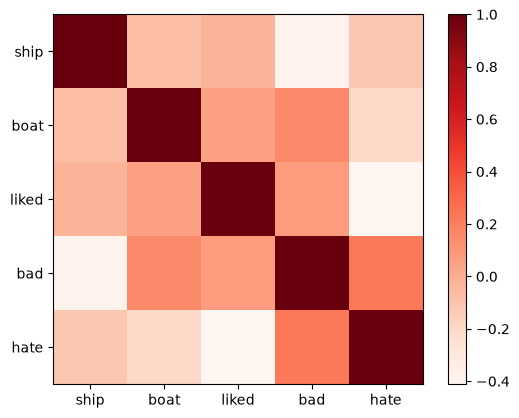

In [74]:
words = ['ship', 'boat', 'liked', 'bad', 'hate']
ids = [token_id(word) for word in words]
similarity = normed_weight[ids] @ normed_weight[ids].T
fig, ax = plt.subplots()
im = ax.imshow(similarity, cmap='Reds')
ax.set(xticks=range(len(words)), yticks=range(len(words)),
       xticklabels=words, yticklabels=words)
fig.colorbar(im, ax=ax)
plt.show()

In [75]:
def get_difference(base, v1, v2):
    base_id, v1_id, v2_id = [token_id(word) for word in (base, v1, v2)]
    target = normed_weight[base_id] + normed_weight[v1_id] - normed_weight[v2_id]
    scores = normed_weight @ target
    scores[[base_id, v1_id, v2_id]] = -float('inf')
    return classifier_tokenizer.convert_ids_to_tokens(scores.argmax().item())

get_difference('bad', 'love', 'hate')

'helped'